In [9]:
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
import pandas as pd
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target

from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(df[data.feature_names], df['target'], test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

print(classification_report(y_train,y_train_pred))
print(classification_report(y_test,y_test_pred))

# overfitting: train_accuracy is 1, but test is significantly lower, indicating that the model is overfitting to the training data.
# underfitting: train_accuracy is low, and test accuracy is also low, indicating that the model is not capturing the underlying patterns in the data.
# good fit: train_accuracy and test_accuracy are both high and similar, indicating that the model is generalizing well to unseen data.

              precision    recall  f1-score   support

           0       0.96      0.93      0.95       169
           1       0.96      0.98      0.97       286

    accuracy                           0.96       455
   macro avg       0.96      0.96      0.96       455
weighted avg       0.96      0.96      0.96       455

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Text(0.5, 1.0, 'Test Confusion Matrix')

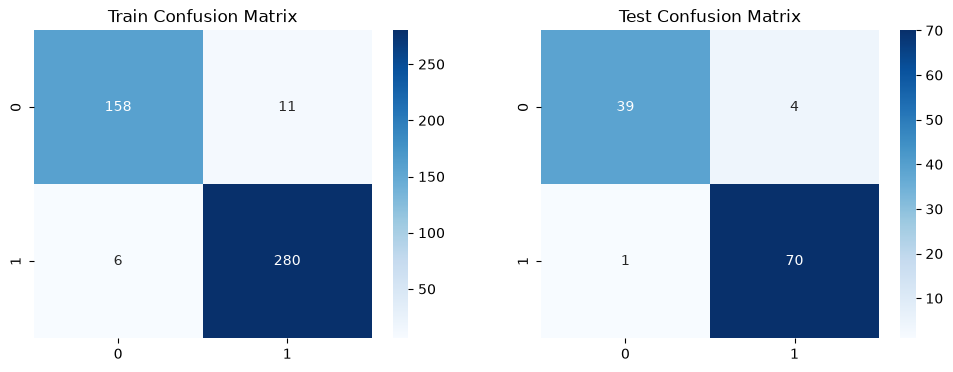

In [10]:
from matplotlib import pyplot as plt
import seaborn as sns
f, ax = plt.subplots(1, 2, figsize=(12, 4)) 
sns.heatmap(cm_train,annot=True,fmt='d',cmap='Blues',ax=ax[0])
ax[0].set_title('Train Confusion Matrix') 
ax[0].set_ylabel('') 
sns.heatmap(cm_test,annot=True,fmt='d',cmap='Blues',ax=ax[1])
ax[1].set_title('Test Confusion Matrix') 

